In [1]:
import pandas as pd
from pandas.plotting import scatter_matrix

import numpy as np
import os
import requests
import tarfile
from tqdm import tqdm
import shutil
from send2trash import send2trash
import matplotlib.pyplot as plt

import sklearn

from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor

from sklearn.model_selection import StratifiedShuffleSplit, train_test_split
from sklearn.impute import SimpleImputer

from sklearn.preprocessing import OrdinalEncoder,OneHotEncoder
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.preprocessing import FunctionTransformer

from sklearn.metrics.pairwise import rbf_kernel

from sklearn.compose import TransformedTargetRegressor
from sklearn.compose import ColumnTransformer, make_column_selector, make_column_transformer

from sklearn.metrics import root_mean_squared_error as rmse
from sklearn.metrics import root_mean_squared_error

from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

sklearn.set_config(display="diagram")
from sklearn.pipeline import Pipeline, make_pipeline

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.validation import check_array, check_is_fitted

In [2]:
def load_housing_data():

    if not os.path.exists('housing.csv'):
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        r = requests.get(url)
        total = int(r.headers.get('content-length'))
        with open('housing.tgz', 'wb') as f:
            with tqdm(total=total) as bar:
                for chunk in r.iter_content(10):
                    size = f.write(chunk)
                    bar.update(size)

        with tarfile.open('housing.tgz') as file:
            file.extractall()
    
        shutil.move('housing/housing.csv', '.')

        send2trash(['housing', 'housing.tgz'])

    return pd.read_csv('housing.csv')

In [3]:
housing = load_housing_data()
housing.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [4]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


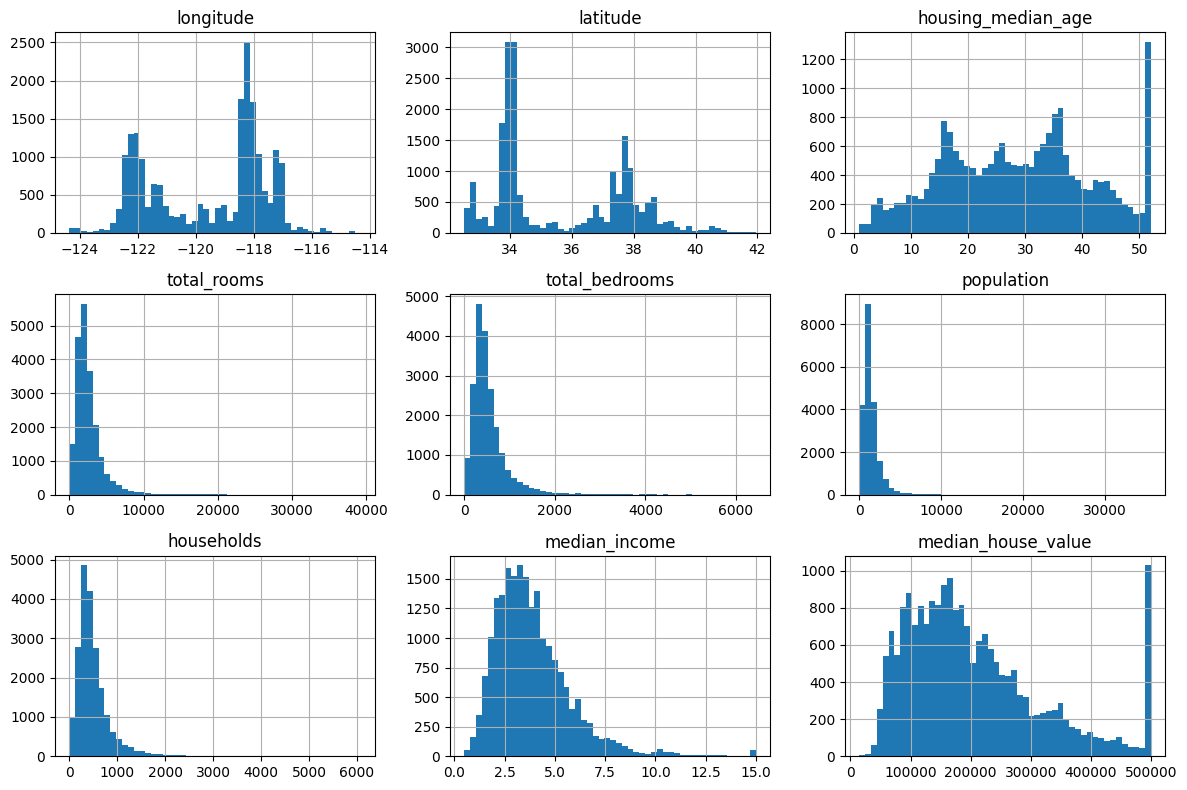

In [5]:
housing.hist(bins=50, figsize=(12, 8), );
plt.tight_layout()

In [6]:
housing['income_cat'] = pd.cut(housing['median_income'], bins=[0., 1.5, 3.0, 4.5, 6., np.inf], labels=[1,2,3,4,5])
housing['income_cat']

0        5
1        5
2        5
3        4
4        3
        ..
20635    2
20636    2
20637    2
20638    2
20639    2
Name: income_cat, Length: 20640, dtype: category
Categories (5, int64): [1 < 2 < 3 < 4 < 5]

In [7]:
strat_train_set, strat_test_set = train_test_split(housing, test_size=0.2, random_state=42, stratify=housing['income_cat'])

In [8]:
for set_ in (strat_train_set, strat_test_set):
    set_.drop('income_cat',axis=1, inplace=True)

In [9]:
housing = strat_train_set.drop("median_house_value", axis=1)
housing_labels = strat_train_set["median_house_value"].copy()

In [10]:
cat_pipeline = make_pipeline(SimpleImputer(strategy="most_frequent"), OneHotEncoder(handle_unknown='ignore'))

In [11]:
class ClusterSimilarity(BaseEstimator, TransformerMixin):
    
    def __init__(self, n_clusters=10, gamma=1.0, random_state=None):
        self.n_clusters = n_clusters
        self.gamma = gamma
        self.random_state = random_state

    def fit(self, x, y=None, sample_weight=None):
        self.kmeans_ = KMeans(self.n_clusters, random_state=self.random_state)
        self.kmeans_.fit(x, sample_weight=sample_weight)
        return self

    def transform(self, x):
        return rbf_kernel(x, self.kmeans_.cluster_centers_, gamma=self.gamma)

    def get_feature_names_out(self, names=None):
        return [f"Cluster {i} similarity" for i in range(self.n_clusters)]

In [12]:
def column_ratio(X):
    return X[:, [0]] / X[:, [1]]
def ratio_name(function_transformer, feature_names_in):
    return ["ratio"]  # feature names out
def ratio_pipeline():
    return make_pipeline(SimpleImputer(strategy="median"),
                         FunctionTransformer(column_ratio, feature_names_out=ratio_name),
                         StandardScaler()
                        )
log_pipeline = make_pipeline(SimpleImputer(strategy="median"),
                             FunctionTransformer(np.log, feature_names_out="one-to-one"),
                             StandardScaler()
                            )
cluster_simil = ClusterSimilarity(n_clusters=10, gamma=1., random_state=42)
default_num_pipeline = make_pipeline(SimpleImputer(strategy="median"),
                                     StandardScaler())
preprocessing = ColumnTransformer([
                                    ("bedrooms", ratio_pipeline(), ["total_bedrooms", "total_rooms"]),
                                    ("rooms_per_house", ratio_pipeline(), ["total_rooms", "households"]),
                                    ("people_per_house", ratio_pipeline(), ["population", "households"]),
                                    ("log", log_pipeline, ["total_bedrooms", "total_rooms", "population",
                                    "households", "median_income"]),
                                    ("geo", cluster_simil, ["latitude", "longitude"]),
                                    ("cat", cat_pipeline, make_column_selector(dtype_include=object)),
                                  ], remainder=default_num_pipeline )  # one column remaining: housing_median_age

In [13]:
full_pipeline = Pipeline([("preprocessing", preprocessing),("random_forest", RandomForestRegressor(random_state=42)),])

In [14]:
param_distribs = {'preprocessing__geo__n_clusters': randint(3, 50),
                  'random_forest__max_features': randint(2, 20)}

In [15]:
rnd_search = RandomizedSearchCV(full_pipeline, param_distribs, n_iter = 10, cv = 3, scoring = 'neg_root_mean_squared_error', random_state=42)

In [16]:
rnd_search.fit(housing, housing_labels)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'preprocessing__geo__n_clusters': <scipy.stats....001F25AA93230>, 'random_forest__max_features': <scipy.stats....001F25BA896D0>}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies th

In [17]:
rnd_search.best_params_

{'preprocessing__geo__n_clusters': 45, 'random_forest__max_features': 9}

In [18]:
pd.DataFrame(rnd_search.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_preprocessing__geo__n_clusters,param_random_forest__max_features,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
0,32.230468,0.829382,0.493123,0.067257,41,16,"{'preprocessing__geo__n_clusters': 41, 'random...",-42580.486638,-42868.652778,-43604.118879,-43017.752765,430.990213,4
1,19.040674,1.399036,0.448784,0.061997,45,9,"{'preprocessing__geo__n_clusters': 45, 'random...",-41204.253373,-42108.203702,-42997.977688,-42103.478254,732.292508,1
2,19.247651,1.292335,0.465861,0.072378,23,8,"{'preprocessing__geo__n_clusters': 23, 'random...",-42420.893552,-42841.063629,-44231.742930,-43164.566704,773.858104,5
3,25.626668,1.372278,0.423962,0.066969,21,12,"{'preprocessing__geo__n_clusters': 21, 'random...",-43418.711853,-43877.545089,-44747.735280,-44014.664074,551.166659,8
4,9.593688,0.155938,0.360588,0.013456,13,5,"{'preprocessing__geo__n_clusters': 13, 'random...",-43676.923671,-44259.689425,-45226.537572,-44387.716889,639.071766,9
5,8.761933,0.329160,0.346947,0.008053,42,4,"{'preprocessing__geo__n_clusters': 42, 'random...",-42030.576161,-42968.400482,-43616.526368,-42871.834337,651.052112,3
6,7.027854,0.309351,0.359928,0.019391,24,3,"{'preprocessing__geo__n_clusters': 24, 'random...",-42827.549496,-43580.399117,-44862.250967,-43756.733193,839.969364,7
7,26.883861,1.234538,0.386952,0.034713,26,13,"{'preprocessing__geo__n_clusters': 26, 'random...",-43062.803706,-43375.658228,-44082.273421,-43506.911785,426.419392,6
8,16.147377,0.891469,0.467433,0.090925,32,7,"{'preprocessing__geo__n_clusters': 32, 'random...",-41991.365603,-42556.901035,-43431.427462,-42659.898033,592.396728,2
9,4.929322,0.028546,0.352417,0.017827,4,2,"{'preprocessing__geo__n_clusters': 4, 'random_...",-50542.400430,-50529.356868,-52341.843532,-51137.866943,851.356663,10


In [19]:
pd.DataFrame(rnd_search.cv_results_).reindex(index=(pd.DataFrame(rnd_search.cv_results_)['mean_test_score'] * -1).sort_values().index)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_preprocessing__geo__n_clusters,param_random_forest__max_features,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
1,19.040674,1.399036,0.448784,0.061997,45,9,"{'preprocessing__geo__n_clusters': 45, 'random...",-41204.253373,-42108.203702,-42997.977688,-42103.478254,732.292508,1
8,16.147377,0.891469,0.467433,0.090925,32,7,"{'preprocessing__geo__n_clusters': 32, 'random...",-41991.365603,-42556.901035,-43431.427462,-42659.898033,592.396728,2
5,8.761933,0.329160,0.346947,0.008053,42,4,"{'preprocessing__geo__n_clusters': 42, 'random...",-42030.576161,-42968.400482,-43616.526368,-42871.834337,651.052112,3
0,32.230468,0.829382,0.493123,0.067257,41,16,"{'preprocessing__geo__n_clusters': 41, 'random...",-42580.486638,-42868.652778,-43604.118879,-43017.752765,430.990213,4
2,19.247651,1.292335,0.465861,0.072378,23,8,"{'preprocessing__geo__n_clusters': 23, 'random...",-42420.893552,-42841.063629,-44231.742930,-43164.566704,773.858104,5
7,26.883861,1.234538,0.386952,0.034713,26,13,"{'preprocessing__geo__n_clusters': 26, 'random...",-43062.803706,-43375.658228,-44082.273421,-43506.911785,426.419392,6
6,7.027854,0.309351,0.359928,0.019391,24,3,"{'preprocessing__geo__n_clusters': 24, 'random...",-42827.549496,-43580.399117,-44862.250967,-43756.733193,839.969364,7
3,25.626668,1.372278,0.423962,0.066969,21,12,"{'preprocessing__geo__n_clusters': 21, 'random...",-43418.711853,-43877.545089,-44747.735280,-44014.664074,551.166659,8
4,9.593688,0.155938,0.360588,0.013456,13,5,"{'preprocessing__geo__n_clusters': 13, 'random...",-43676.923671,-44259.689425,-45226.537572,-44387.716889,639.071766,9
9,4.929322,0.028546,0.352417,0.017827,4,2,"{'preprocessing__geo__n_clusters': 4, 'random_...",-50542.400430,-50529.356868,-52341.843532,-51137.866943,851.356663,10


In [20]:
final_model = rnd_search.best_estimator_

In [21]:
x_test = strat_test_set.drop("median_house_value", axis=1)
y_test = strat_test_set["median_house_value"].copy()

final_predictions = final_model.predict(x_test)

final_rmse = rmse(y_test, final_predictions)
final_rmse

41422.168800999665

In [22]:
from scipy import stats

confidence = 0.95
squared_errors = (final_predictions - y_test) ** 2
np.sqrt(stats.t.interval(confidence, len(squared_errors) - 1,
                             loc=squared_errors.mean(), scale=stats.sem(squared_errors)))

array([39272.70918656, 43465.46272048])

In [23]:
import joblib
joblib.dump(final_model, "my_california_housing_model.pkl")

['my_california_housing_model.pkl']